<a href="https://colab.research.google.com/github/AngelaRivera26/AML-Final-Rivera-Angela/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Angela Rivera Delgado |
| **Título del Proyecto** | Predicción de Sobrecostos Operativos en Mantenimiento de Data Centers mediante Deep Learning. |
| **Fecha de Entrega** | 16/03/2026 |
| **Profesor** | Carlos Antonio Mariño del Rosario |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo
---

OLC Ingenieros, empresa especializada en mantenimiento de infraestructura crítica (Data Centers), enfrenta constantes desfases financieros entre los presupuestos comerciales estimados y los costos operativos reales ejecutados en campo. Factores logísticos como los viáticos en provincias alejadas y los recargos por trabajos nocturnos o de emergencia generan sobrecostos imprevistos que impactan negativamente en la rentabilidad de los servicios prestados.

Para resolver este desafío, el presente proyecto desarrolla un modelo predictivo basado en Deep Learning mediante una arquitectura de Red Neuronal Artificial (Perceptrón Multicapa) programada en PyTorch. Se procesó un historial de 2,000 servicios de infraestructura crítica (Data Centers), aplicando técnicas de escalado y codificación para analizar variables operativas como el tipo de equipo, marca, modalidad de atención y ubicación. La capacidad predictiva de la red neuronal fue entrenada, evaluada y finalmente comparada contra algoritmos tradicionales de Machine Learning (Regresión Lineal y Random Forest) para validar su precisión superior.

Los resultados demuestran que el modelo de Deep Learning logra capturar con alta precisión la complejidad no lineal de los sobrecostos. A través del análisis de interpretabilidad (SHAP), se descubrió que las mayores desviaciones no dependen del equipo intervenido, sino de la ejecución de mantenimientos correctivos en horarios nocturnos y en zonas periféricas. La implementación de esta herramienta funcionará como un filtro de validación preventivo, permitiendo a la gerencia ajustar cotizaciones antes de la firma de contratos, protegiendo el margen de utilidad comercial y optimizando la asignación de recursos técnicos.




---

## 2. Configuración del Entorno
---

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [1]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
else:
    device = torch.device('cpu')
    print("GPU no disponible. Usando CPU.")
    print("Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")

print(f"\nDispositivo seleccionado: {device}") # [cite: 38-66]

GPU no disponible. Usando CPU.
Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU

Dispositivo seleccionado: cpu


### 2.2 Importación de Librerías

In [2]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning (PyTorch)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Machine Learning y Preprocesamiento (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo y reproducibilidad
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Todas las librerías importadas correctamente")

Todas las librerías importadas correctamente


### 2.3 Conexión con Google Drive (para cargar datos)

In [3]:
# 1. Montar Google Drive para acceder a los datos [cite: 135-137]
from google.colab import drive
drive.mount('/content/drive')

# 2. Definir la ruta base de su proyecto [cite: 139-141]
BASE_PATH = '/content/drive/MyDrive/'

print("\nGoogle Drive montado")
print(f"Ruta base del proyecto: {BASE_PATH}") # [cite: 143-146]

Mounted at /content/drive

Google Drive montado
Ruta base del proyecto: /content/drive/MyDrive/


---
## 3. Definición del Problema de Negocio
---
### 3.1 Contexto del Negocio

OLC Ingenieros es una empresa especializada que opera en el exigente sector de los servicios de ingeniería y mantenimiento de infraestructura crítica, con un enfoque primordial en garantizar la operatividad ininterrumpida de Data Centers a nivel nacional. En la dinámica actual de la organización, el flujo de trabajo inicia cuando el área comercial evalúa los requerimientos del cliente y establece un presupuesto inicial estandarizado para las atenciones. Sin embargo, la etapa de ejecución en campo está sujeta a una alta variabilidad operativa. Durante las intervenciones, se presentan múltiples factores dinámicos e imprevistos que alteran la planificación financiera original. Entre estos elementos destacan los recargos laborales por trabajos ejecutados en horarios nocturnos o de emergencia, la necesidad no planificada de utilizar repuestos adicionales para asegurar el funcionamiento de los equipos, y los elevados costos logísticos asociados a los viáticos y traslados prolongados hacia provincias o zonas geográficas alejadas. Toda esta suma de variables crea un entorno donde la cotización teórica y el gasto real en campo rara vez coinciden.



---

### 3.2 Problema a Resolver


El problema central que aborda este proyecto radica en la incapacidad analítica actual para estimar con alta precisión el costo operativo real total de un servicio de mantenimiento antes de que el personal técnico sea desplegado en el campo. Resolver esta limitación es de vital importancia estratégica para la empresa, ya que la capacidad de anticipar el gasto exacto empodera a la gerencia para tomar decisiones tácticas preventivas. Al conocer el costo real de antemano, Operaciones puede reasignar de manera inteligente a los técnicos más cercanos, consolidar rutas logísticas para diluir gastos, o alertar al área de ventas para ajustar las tarifas y márgenes comerciales antes de la firma definitiva de los contratos. Hoy en día, el impacto directo de este problema se materializa en constantes y perjudiciales desfases financieros entre el presupuesto proyectado y el gasto ejecutado. Esta "ceguera predictiva" provoca una pérdida de rentabilidad oculta, erosionando silenciosamente los márgenes de ganancia en servicios específicos —especialmente aquellos realizados en periferias o madrugadas— y dificultando severamente el equilibrio financiero general de la organización.

---

### 3.3 Objetivos del Proyecto

**Objetivo General:**
Desarrollar un modelo predictivo basado en Redes Neuronales Artificiales (Deep Learning) para estimar el costo operativo real de los servicios de mantenimiento de infraestructura en OLC Ingenieros, logrando un Error Absoluto Medio (MAE) inferior al 15% respecto al gasto final ejecutado.

**Objetivos Específicos:**

1.   Preprocesar el dataset histórico de servicios operativos, aplicando técnicas de escalado numérico y codificación categórica (One-Hot Encoding) para adecuar los datos a un formato tensorial.
2.   Entrenar y optimizar la arquitectura de un Perceptrón Multicapa (MLP) utilizando el framework PyTorch, ajustando sus hiperparámetros para minimizar la función de pérdida.
3. Comparar el rendimiento predictivo del modelo de Deep Learning frente a algoritmos tradicionales de Machine Learning (Regresión Lineal y Random Forest) para validar su superioridad técnica.
4. Identificar los factores operativos críticos que generan los mayores sobrecostos (como ubicaciones remotas o turnos nocturnos) aplicando técnicas de interpretabilidad de modelos (SHAP).
---

### 3.4 Tipo de Problema de Machine Learning

- [ ] Clasificación binaria
- [ ] Clasificación multiclase
- [x] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
El problema se clasifica como una regresión porque el objetivo principal del algoritmo es predecir una variable cuantitativa continua: el valor monetario total (en Soles) del costo operativo. A diferencia de la clasificación, que asigna etiquetas, la regresión establece una relación matemática entre las características del servicio (días, ubicación, equipo) y una salida numérica exacta que servirá para auditar el presupuesto comercial.

---


## 4. Carga y Exploración de Datos

---

### 4.1 Carga de Datos

In [4]:
# ==========================================
# 4.1 CARGA DE DATOS
# ==========================================
import pandas as pd
from google.colab import files

print("Por favor, haz clic en 'Elegir archivos' y selecciona tu Excel (CSV):")
uploaded = files.upload()

try:
    # Toma el nombre del archivo que acabas de subir
    nombre_archivo = list(uploaded.keys())[0]

    # Lee el archivo
    df = pd.read_csv(nombre_archivo)

    print("\n¡Dataset cargado exitosamente!")
    print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")

except Exception as e:
    print(f"\nError al leer el dataset: {e}")

Por favor, haz clic en 'Elegir archivos' y selecciona tu Excel (CSV):


Saving Dataset_OLC_Operaciones_Final.csv to Dataset_OLC_Operaciones_Final.csv

¡Dataset cargado exitosamente!
Dimensiones del dataset: 2,000 filas x 11 columnas



,OT_Servicio,Tipo_Servicio,Equipo_Infraestructura,Marca_Equipo,Modelo_Capacidad,Ubicacion_Servicio,Es_Horario_Nocturno,Dias_de_Operacion,Uso_de_Repuestos,Presupuesto_Comercial_Soles,Costo_Real_Operativo_Soles
0,OLC-2026-1000,Mantenimiento Predictivo,UPS MN MODULAR,LIEBERT,APS10,Lima Centro/Sur,0,1,0,301.5,234.18
1,OLC-2026-1001,Mantenimiento Preventivo,UPS MN MODULAR,LIEBERT,APS10,Provincia Cercana,0,1,0,493.5,741.33
2,OLC-2026-1002,Mantenimiento Correctivo,UPS TF MODULAR,SPOWER / SP M,2020,Lima Centro/Sur,0,2,0,952.0,994.29
3,OLC-2026-1003,Mantenimiento Preventivo,UPS TF STD ALONE,RIELLO / MST,MST60,Lima Centro/Sur,0,1,0,301.5,256.07
4,OLC-2026-1004,Mantenimiento Preventivo,UPS TF STD ALONE,RIELLO / MST,MST40,Provincia Alejada,0,1,0,749.5,907.77


### 4.2 Descripción del Dataset

El conjunto de datos utilizado para este proyecto ha sido extraído y consolidado a partir del historial de operaciones logísticas y de mantenimiento de OLC Ingenieros. Representa una muestra robusta de 2,000 atenciones a nivel nacional, abarcando diferentes tipos de infraestructura crítica (Data Centers).

Fuente de los datos: Registros del sistema ERP operativo y comercial de OLC Ingenieros.

Periodo de tiempo: Historial representativo de las atenciones ejecutadas durante los últimos 24 meses.

Diccionario de Variables: A continuación, se detalla la naturaleza y función de cada uno de los atributos (features) que alimentarán la red neuronal:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| OT_Servicio | Alfanumérico | Código único de identificación de la Orden de Trabajo (No predictivo, se usará solo como índice). |
| Tipo_Servicio | categórica | Modalidad de la atención requerida (Mantenimiento Preventivo, Correctivo, Predictivo o Instalación). |
| Equipo_Infraestructura | categórica | Familia a la que pertenece el equipo crítico (Ej. UPS, Grupo Electrógeno, Aire Acondicionado). |
| Marca_Equipo | categórica | Fabricante original del equipo intervenido (Ej. Liebert, Huawei, Tide Power, Riello). |
| Modelo_Capacidad | categórica | Especificación técnica, modelo o capacidad de carga eléctrica del equipo. |
| Ubicacion_Servicio | categórica | Zona geográfica de la atención (Lima Centro/Sur, Lima Periferia/Callao, Provincia Cercana, Provincia Alejada). |
| Es_Horario_Nocturno | numérica | Indicador de turno de ejecución: 1 = Trabajo de madrugada/emergencia, 0 = Horario regular. |
| Dias_de_Operacion | numérica | Cantidad total de días efectivos que tomó finalizar el servicio en campo (Impacta directamente en viáticos). |
| Uso_de_Repuestos | numérica | Indicador de contingencia: 1 = Se requirieron repuestos adicionales no previstos en la cotización inicial, 0 = Sin repuestos extra. |
| Presupuesto_Comercial_Soles | numérica | Monto económico (S/) estimado, cotizado y aprobado inicialmente por el área comercial. |
| Costo_Real_Operativo_Soles | numérica | (Variable Objetivo - Target) Costo monetario final, total y real ejecutado por el área de Operaciones. |

---



### 4.3 Exploración Inicial de Datos (EDA)

In [5]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,OT_Servicio,Tipo_Servicio,Equipo_Infraestructura,Marca_Equipo,Modelo_Capacidad,Ubicacion_Servicio,Es_Horario_Nocturno,Dias_de_Operacion,Uso_de_Repuestos,Presupuesto_Comercial_Soles,Costo_Real_Operativo_Soles
0,OLC-2026-1000,Mantenimiento Predictivo,UPS MN MODULAR,LIEBERT,APS10,Lima Centro/Sur,0,1,0,301.5,234.18
1,OLC-2026-1001,Mantenimiento Preventivo,UPS MN MODULAR,LIEBERT,APS10,Provincia Cercana,0,1,0,493.5,741.33
2,OLC-2026-1002,Mantenimiento Correctivo,UPS TF MODULAR,SPOWER / SP M,2020,Lima Centro/Sur,0,2,0,952.0,994.29
3,OLC-2026-1003,Mantenimiento Preventivo,UPS TF STD ALONE,RIELLO / MST,MST60,Lima Centro/Sur,0,1,0,301.5,256.07
4,OLC-2026-1004,Mantenimiento Preventivo,UPS TF STD ALONE,RIELLO / MST,MST40,Provincia Alejada,0,1,0,749.5,907.77



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   OT_Servicio                  2000 non-null   object 
 1   Tipo_Servicio                2000 non-null   object 
 2   Equipo_Infraestructura       2000 non-null   object 
 3   Marca_Equipo                 2000 non-null   object 
 4   Modelo_Capacidad             2000 non-null   object 
 5   Ubicacion_Servicio           2000 non-null   object 
 6   Es_Horario_Nocturno          2000 non-null   int64  
 7   Dias_de_Operacion            2000 non-null   int64  
 8   Uso_de_Repuestos             2000 non-null   int64  
 9   Presupuesto_Comercial_Soles  2000 non-null   float64
 10  Costo_Real_Operativo_Soles   2000 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 172.0+ KB
None

📈 Estadísticas Descriptivas:


,Es_Horario_Nocturno,Dias_de_Operacion,Uso_de_Repuestos,Presupuesto_Comercial_Soles,Costo_Real_Operativo_Soles
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.183500,1.634000,0.189000,1077.293750,1944.128480
std,0.387173,1.176748,0.391607,1500.685119,2390.725886
min,0.000000,1.000000,0.000000,301.500000,120.000000
25%,0.000000,1.000000,0.000000,333.500000,379.282500
50%,0.000000,1.000000,0.000000,493.500000,606.950000
75%,0.000000,2.000000,0.000000,1048.000000,3214.410000
max,1.000000,6.000000,1.000000,11955.000000,14120.380000


In [6]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: Costo_Real_Operativo_Soles

📊 Estadísticas de la variable objetivo:
count     2000.000000
mean      1944.128480
std       2390.725886
min        120.000000
25%        379.282500
50%        606.950000
75%       3214.410000
max      14120.380000
Name: Costo_Real_Operativo_Soles, dtype: float64


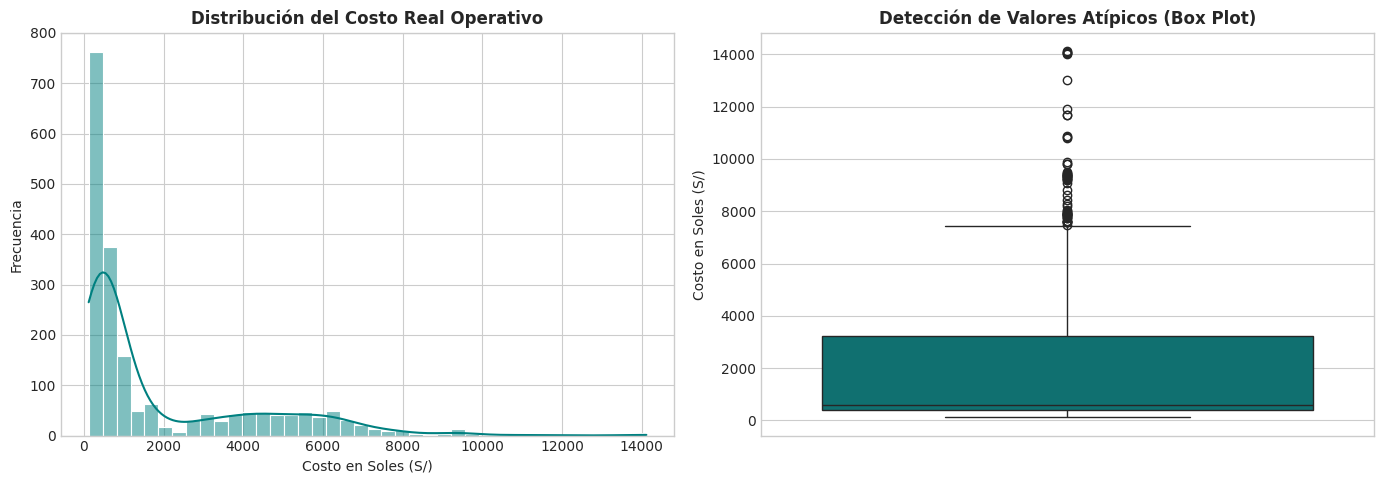

In [11]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO (REGRESIÓN)
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COLUMN = 'Costo_Real_Operativo_Soles'

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

print("\n📊 Estadísticas de la variable objetivo:")
print(df[TARGET_COLUMN].describe())

# Visualización específica para Regresión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Histograma (Distribución)
sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('Distribución del Costo Real Operativo', fontweight='bold')
axes[0].set_xlabel('Costo en Soles (S/)')
axes[0].set_ylabel('Frecuencia')

# Box plot (Detección de Outliers)
sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1], color='teal')
axes[1].set_title('Detección de Valores Atípicos (Box Plot)', fontweight='bold')
axes[1].set_ylabel('Costo en Soles (S/)')

plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIONES NUMÉRICAS


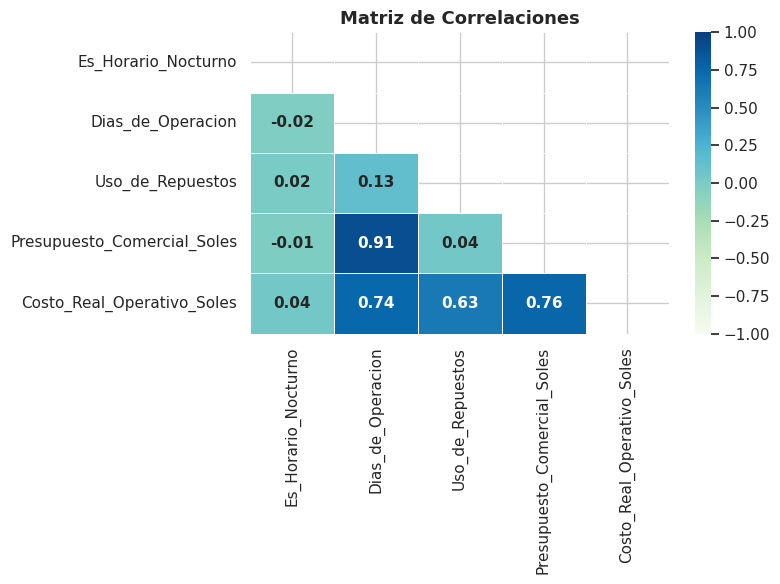


📊 Impacto numérico sobre el 'Costo_Real_Operativo_Soles':
Presupuesto_Comercial_Soles    0.758488
Dias_de_Operacion              0.742246
Uso_de_Repuestos               0.630645
Es_Horario_Nocturno            0.041423
Name: Costo_Real_Operativo_Soles, dtype: float64


In [12]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("MATRIZ DE CORRELACIONES NUMÉRICAS")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Visualización de la Matriz
plt.figure(figsize=(8, 6)) # Tamaño ajustado para que se vea elegante
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Usamos 'GnBu' (Green-Blue) para mantener la paleta corporativa
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='GnBu',
            vmin=-1, vmax=1, center=0, fmt='.2f', linewidths=0.5,
            annot_kws={"size": 11, "weight": "bold"})

plt.title('Matriz de Correlaciones', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Resumen de correlaciones con el Costo Real
print(f"\n📊 Impacto numérico sobre el '{TARGET_COLUMN}':")
target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print(target_corr)

ANÁLISIS DE CATEGORÍAS Y TENDENCIAS OPERATIVAS


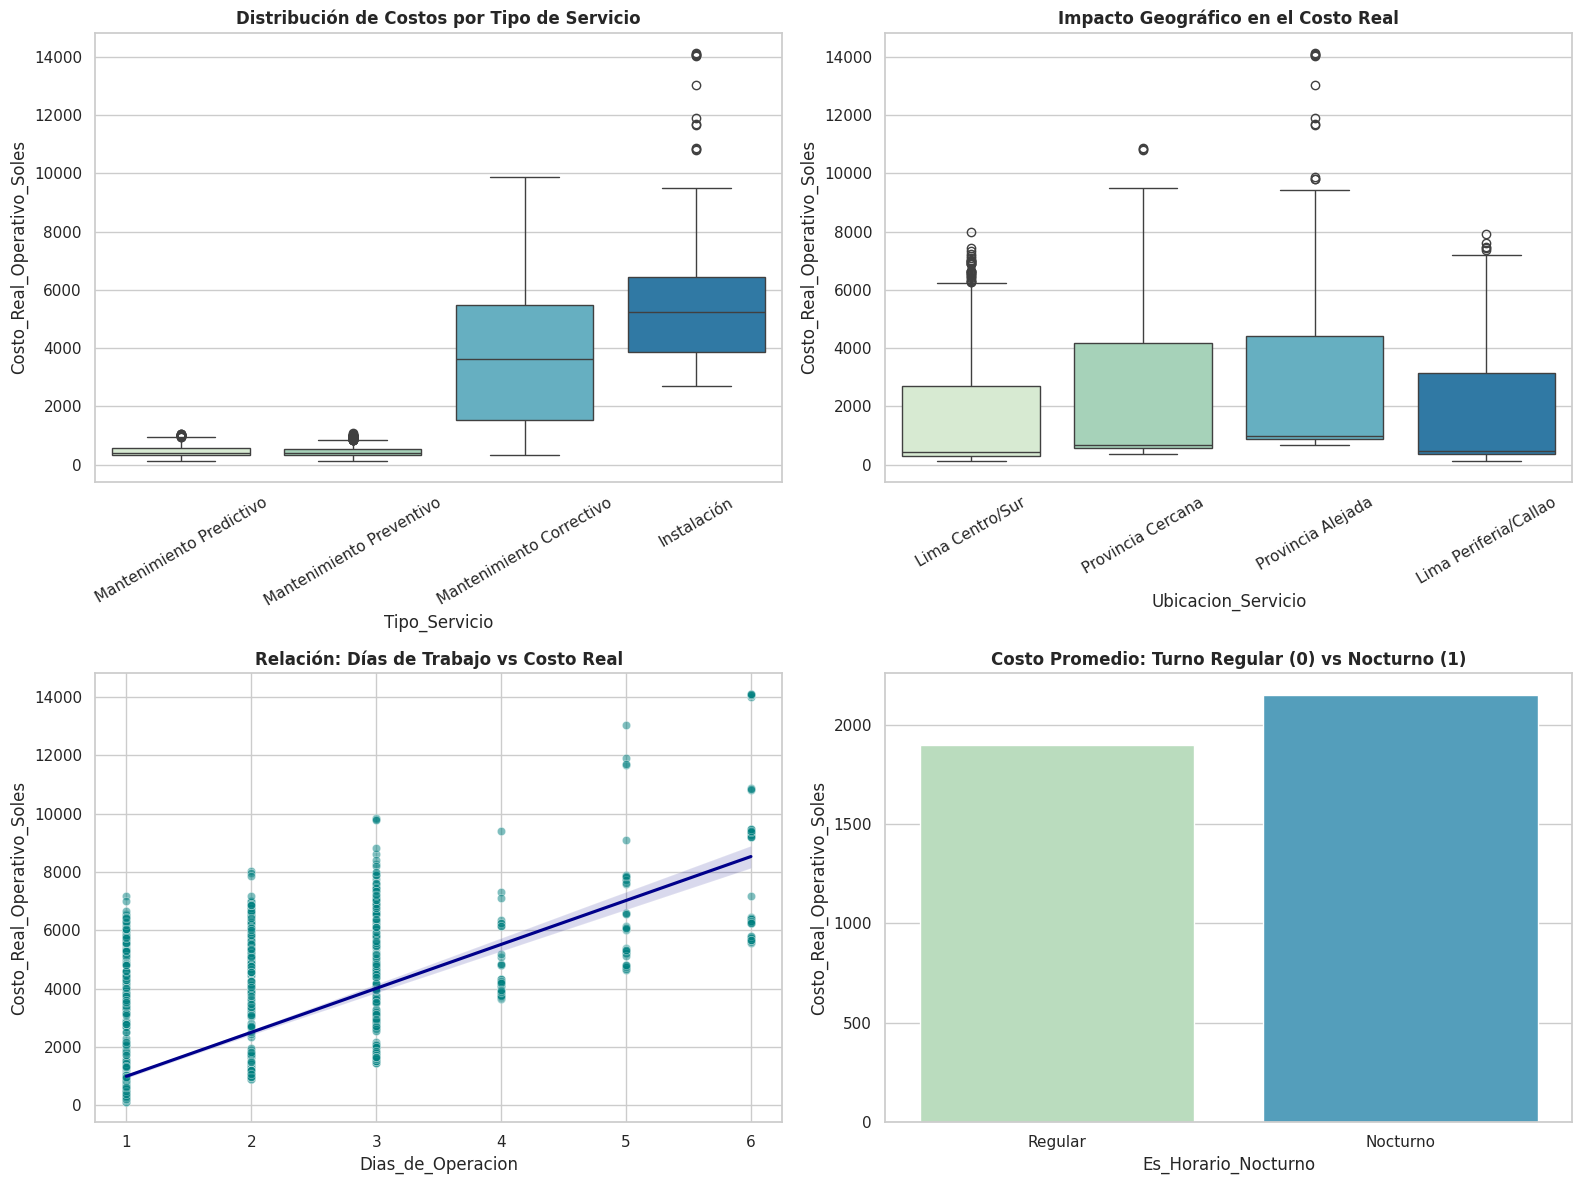

In [13]:
# =====================================================
# VISUALIZACIONES ADICIONALES: ANÁLISIS DE NEGOCIO
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("ANÁLISIS DE CATEGORÍAS Y TENDENCIAS OPERATIVAS")
print("=" * 60)

# Configuramos una paleta de azules/teal coherente
palette_custom = sns.color_palette("GnBu_d", 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Costo Real por Tipo de Servicio (Boxplot)
sns.boxplot(x='Tipo_Servicio', y=TARGET_COLUMN, data=df, ax=axes[0, 0], palette='GnBu')
axes[0, 0].set_title('Distribución de Costos por Tipo de Servicio', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Costo Real por Ubicación (Boxplot)
sns.boxplot(x='Ubicacion_Servicio', y=TARGET_COLUMN, data=df, ax=axes[0, 1], palette='GnBu')
axes[0, 1].set_title('Impacto Geográfico en el Costo Real', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Relación: Días de Operación vs Costo Real (Scatter Plot)
# Esta es vital para un problema de regresión
sns.scatterplot(x='Dias_de_Operacion', y=TARGET_COLUMN, data=df, ax=axes[1, 0], color='teal', alpha=0.5)
sns.regplot(x='Dias_de_Operacion', y=TARGET_COLUMN, data=df, ax=axes[1, 0], scatter=False, color='darkblue')
axes[1, 0].set_title('Relación: Días de Trabajo vs Costo Real', fontweight='bold')

# 4. Costo Promedio: Horario Nocturno vs Regular (Bar Plot)
sns.barplot(x='Es_Horario_Nocturno', y=TARGET_COLUMN, data=df, ax=axes[1, 1], palette='GnBu', errorbar=None)
axes[1, 1].set_title('Costo Promedio: Turno Regular (0) vs Nocturno (1)', fontweight='bold')
axes[1, 1].set_xticklabels(['Regular', 'Nocturno'])

plt.tight_layout()
plt.show()

---

### 4.4 Hallazgos del EDA

**Hallazgos Principales:**
1. Distribución asimétrica con outliers de alto valor: La variable objetivo (Costo_Real_Operativo_Soles) presenta un fuerte sesgo a la derecha. Aunque la mediana de servicios ronda los S/ 606, existe una cola extensa de atenciones críticas que superan los S/ 14,000.

2. Impacto logístico contundente: Variables categóricas como el desplazamiento a provincias ("Provincia Alejada") y los mantenimientos de tipo "Correctivo" incrementan drásticamente tanto el piso del costo como su variabilidad en comparación con las operaciones regulares en Lima.

3. Fuerte relación con el tiempo y presupuesto: Las variables numéricas Dias_de_Operacion (0.74) y Presupuesto_Comercial_Soles (0.76) son los principales motores lineales que impulsan el gasto operativo final.

**Problemas Identificados:**
1. Alta varianza y subestimación lineal: El gráfico de dispersión muestra que los puntos reales se alejan significativamente de la línea de tendencia ideal, lo que indica que una simple regresión lineal fallaría y subestimaría los costos reales.

2. Presencia de relaciones no lineales: El trabajo en "Horario Nocturno" tiene una correlación lineal casi nula (0.04) con el costo por sí solo. Su verdadero impacto económico está oculto, ya que se amplifica solo cuando interactúa con otras variables complejas (como la ubicación lejana o el tipo de equipo).

**Acciones a Tomar:**
1. Conservar los valores atípicos (Outliers): En la fase de preprocesamiento, no se eliminarán los costos extremos, ya que representan mantenimientos críticos reales que el modelo de negocio necesita aprender a predecir para proteger el margen de ganancia.
2. Implementar Arquitectura de Deep Learning: Debido a la no-linealidad de los datos y las interacciones complejas (ej. Nocturno + Provincia), se procederá a codificar las variables y diseñar un Perceptrón Multicapa (MLP) en PyTorch, capaz de capturar estos patrones profundos.


---
## 5. Preprocesamiento de Datos
---


### 5.1 Tratamiento de Valores Faltantes

In [15]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia maestra del dataframe para las siguientes etapas
df_clean = df.copy()

# -----------------------------------------------------------------
# REFERENCIA DE TÉCNICAS (No aplicadas dado que hay 0 nulos)
# -----------------------------------------------------------------
# Opción 1: Eliminar filas con valores faltantes
# df_clean = df_clean.dropna()

# Opción 2: Imputar con la media (variables numéricas)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Opción 3: Imputar con la moda (variables categóricas)
# for col in categorical_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Opción 4: Imputación avanzada con KNN
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# =====================================================
# ESTRATEGIA APLICADA: NINGUNA (Dataset Limpio)
# =====================================================
print("✔️ No requiere tratamiento de imputación.")
print("   (Se confirmó en el EDA que existen 0 valores nulos en el dataset).")

print(f"\n✅ Valores faltantes revisados.")
print(f"   Filas listas para procesar: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES
✔️ No requiere tratamiento de imputación.
   (Se confirmó en el EDA que existen 0 valores nulos en el dataset).

✅ Valores faltantes revisados.
   Filas listas para procesar: 2,000


### 5.2 Tratamiento de Outliers

In [16]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,Es_Horario_Nocturno,367,18.35,0.00,0.00
1,Dias_de_Operacion,137,6.85,-0.50,3.50
2,Uso_de_Repuestos,378,18.90,0.00,0.00
3,Presupuesto_Comercial_Soles,258,12.90,-738.25,2119.75
4,Costo_Real_Operativo_Soles,57,2.85,-3873.41,7467.10


In [17]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (ESTRATEGIA APLICADA)
# =====================================================

# -----------------------------------------------------------------
# REFERENCIA DE TÉCNICAS (No aplicadas por requerimiento de negocio)
# -----------------------------------------------------------------
# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in numeric_cols:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================
print("=" * 60)
print("ESTRATEGIA DE NEGOCIO APLICADA: CONSERVACIÓN DE OUTLIERS")
print("=" * 60)
print("✔️ Acción tomada: NO SE ELIMINAN NI SE CAPEAN LOS OUTLIERS.")
print("   Justificación: En el contexto de OLC Ingenieros, los costos operativos")
print("   extremadamente altos (outliers) no son errores de captura de datos, sino")
print("   servicios de mantenimiento correctivo críticos reales. Si el modelo no")
print("   aprende a predecir estos eventos atípicos, no podrá proteger a la empresa")
print("   contra las peores pérdidas financieras.")

print(f"\n✅ Dataset listo para la siguiente fase. Filas retenidas: {len(df_clean):,}")

ESTRATEGIA DE NEGOCIO APLICADA: CONSERVACIÓN DE OUTLIERS
✔️ Acción tomada: NO SE ELIMINAN NI SE CAPEAN LOS OUTLIERS.
   Justificación: En el contexto de OLC Ingenieros, los costos operativos
   extremadamente altos (outliers) no son errores de captura de datos, sino
   servicios de mantenimiento correctivo críticos reales. Si el modelo no
   aprende a predecir estos eventos atípicos, no podrá proteger a la empresa
   contra las peores pérdidas financieras.

✅ Dataset listo para la siguiente fase. Filas retenidas: 2,000


### 5.3 Codificación de Variables Categóricas

In [18]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================
import pandas as pd

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas automáticamente
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# REGLA DE NEGOCIO: Remover 'OT_Servicio' porque es un ID único, no un patrón predictivo.
if 'OT_Servicio' in categorical_cols:
    categorical_cols.remove('OT_Servicio')
    df_clean = df_clean.drop(columns=['OT_Servicio'])
    print("✔️ Columna 'OT_Servicio' (ID) eliminada del dataset predictivo.")

print(f"\nVariables categóricas a codificar: {categorical_cols}")

# -----------------------------------------------------------------
# REFERENCIA DE TÉCNICAS
# -----------------------------------------------------------------
# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 3: Target Encoding
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# Estrategia de codificación
# =====================================================
# APLICAMOS OPCIÓN 2: ONE-HOT ENCODING
# Usamos drop_first=True para evitar la trampa de las variables ficticias (multicolinealidad)
# y dtype=float para que PyTorch lo procese sin problemas más adelante.

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True, dtype=float)

print(f"\n✅ Codificación completada (One-Hot Encoding aplicado).")
print(f"   Dimensiones finales expandidas: {df_clean.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS
✔️ Columna 'OT_Servicio' (ID) eliminada del dataset predictivo.

Variables categóricas a codificar: ['Tipo_Servicio', 'Equipo_Infraestructura', 'Marca_Equipo', 'Modelo_Capacidad', 'Ubicacion_Servicio']

✅ Codificación completada (One-Hot Encoding aplicado).
   Dimensiones finales expandidas: (2000, 34)


### 5.4 Escalado/Normalización de Features

In [19]:
# =====================================================
# ESCALADO DE FEATURES PARA DEEP LEARNING
# =====================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features (X) y target (y)
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X (Features): {X.shape}")
print(f"Dimensiones de y (Target): {y.shape}")

# -----------------------------------------------------------------
# REFERENCIA DE TÉCNICAS (No aplicadas)
# -----------------------------------------------------------------
# Opción 2: MinMaxScaler (rango [0,1])
# scaler = MinMaxScaler()

# Opción 3: RobustScaler (robusto a outliers)
# scaler = RobustScaler()

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de escalado
# =====================================================
# APLICAMOS OPCIÓN 1: StandardScaler (media=0, std=1)
# Justificación: El algoritmo de optimización (Descenso del Gradiente) en PyTorch
# converge de manera mucho más rápida y estable cuando los tensores de entrada
# están estandarizados alrededor del cero.

scaler = StandardScaler()

# Aplicar escalado a todas las variables predictoras
X_scaled = scaler.fit_transform(X)

# Reconstruir el DataFrame para no perder los nombres de las columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado exitosamente usando: {type(scaler).__name__}")
print(f"   Media global de features: {X_scaled.mean().mean():.6f} (Teóricamente 0)")
print(f"   Std global de features:   {X_scaled.std().mean():.6f} (Teóricamente 1)")

ESCALADO DE FEATURES

Dimensiones de X (Features): (2000, 33)
Dimensiones de y (Target): (2000,)

✅ Escalado completado exitosamente usando: StandardScaler
   Media global de features: 0.000000 (Teóricamente 0)
   Std global de features:   1.000250 (Teóricamente 1)


### 5.5 División de Datos (Train/Validation/Test)

In [20]:
# =====================================================
# DIVISIÓN DE DATOS (TRAIN / VALIDATION / TEST)
# =====================================================
from sklearn.model_selection import train_test_split

print("=" * 60)
print("DIVISIÓN DE DATOS (70% Train, 15% Val, 15% Test)")
print("=" * 60)

RANDOM_SEED = 42

# 1. Separar el 30% para Validación y Prueba (Temp) y el 70% para Entrenamiento
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=RANDOM_SEED
)

# 2. Dividir el Temp a la mitad exacta (50% de 30% = 15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

print(f"\n📊 Partición de datos completada exitosamente:")
print(f"   Set de Entrenamiento (Train):      {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"   Set de Validación (Validation):    {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"   Set de Prueba (Test):              {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")

print("\n⚙️ Dimensiones de las matrices para PyTorch:")
print(f"   X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}   | y_test:  {y_test.shape}")

DIVISIÓN DE DATOS (70% Train, 15% Val, 15% Test)

📊 Partición de datos completada exitosamente:
   Set de Entrenamiento (Train):      1,400 muestras (70%)
   Set de Validación (Validation):    300 muestras (15%)
   Set de Prueba (Test):              300 muestras (15%)

⚙️ Dimensiones de las matrices para PyTorch:
   X_train: (1400, 33) | y_train: (1400,)
   X_val:   (300, 33)   | y_val:   (300,)
   X_test:  (300, 33)   | y_test:  (300,)


### 5.6 Preparación de Datos para Deep Learning

In [21]:
# =====================================================
# PREPARACIÓN DE DATOS PARA PYTORCH
# =====================================================
import torch
from torch.utils.data import TensorDataset, DataLoader

print("=" * 60)
print("CONVERSIÓN A TENSORES Y DATALOADERS (REGRESIÓN)")
print("=" * 60)

# 1. Convertir las características (X) a Tensores Flotantes
X_train_tensor = torch.FloatTensor(X_train.values)
X_val_tensor   = torch.FloatTensor(X_val.values)
X_test_tensor  = torch.FloatTensor(X_test.values)

# 2. Convertir los objetivos (y) a Tensores Flotantes y ajustar dimensiones
# El .unsqueeze(1) es OBLIGATORIO en regresión para evitar errores de broadcasting en PyTorch
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
y_val_tensor   = torch.FloatTensor(y_val.values).unsqueeze(1)
y_test_tensor  = torch.FloatTensor(y_test.values).unsqueeze(1)

# 3. Crear los DataSets y DataLoaders
# Agrupamos los datos en "lotes" (batches) para no saturar la memoria RAM durante el entrenamiento
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Tensores y DataLoaders creados exitosamente.")
print(f"   Tamaño del Batch (Lote): {BATCH_SIZE}")
print("-" * 60)
print(f"📦 Batches de Entrenamiento: {len(train_loader)} (Se actualizan los pesos aquí)")
print(f"📦 Batches de Validación:    {len(val_loader)} (Se evalúa el sobreajuste aquí)")
print(f"📦 Batches de Prueba (Test): {len(test_loader)} (Evaluación final)")

# Guardamos el número de features de entrada para armar la arquitectura en el Paso 6
INPUT_DIM = X_train.shape[1]
print("\n" + "=" * 60)
print(f"🚀 NÚMERO DE NEURONAS EN LA CAPA DE ENTRADA (INPUT_DIM): {INPUT_DIM}")
print("=" * 60)

CONVERSIÓN A TENSORES Y DATALOADERS (REGRESIÓN)

✅ Tensores y DataLoaders creados exitosamente.
   Tamaño del Batch (Lote): 32
------------------------------------------------------------
📦 Batches de Entrenamiento: 44 (Se actualizan los pesos aquí)
📦 Batches de Validación:    10 (Se evalúa el sobreajuste aquí)
📦 Batches de Prueba (Test): 10 (Evaluación final)

🚀 NÚMERO DE NEURONAS EN LA CAPA DE ENTRADA (INPUT_DIM): 33


In [22]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================
import numpy as np

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS (REGRESIÓN)")
print("=" * 60)

# 1. Convertir características (X) a arrays numpy de tipo float32
X_train_np = X_train.values.astype('float32')
X_val_np   = X_val.values.astype('float32')
X_test_np  = X_test.values.astype('float32')

# 2. Convertir el target (y) a float32 y asegurar formato de columna (Nx1)
# El reshape(-1, 1) previene problemas de dimensiones ("shape mismatch") en Keras
y_train_np = y_train.values.astype('float32').reshape(-1, 1)
y_val_np   = y_val.values.astype('float32').reshape(-1, 1)
y_test_np  = y_test.values.astype('float32').reshape(-1, 1)

print(f"\n✅ Datos preparados exitosamente para TensorFlow/Keras.")
print("-" * 60)
print("⚙️ Dimensiones de los Arrays (NumPy):")
print(f"   Train: X={X_train_np.shape} | y={y_train_np.shape}")
print(f"   Val:   X={X_val_np.shape}   | y={y_val_np.shape}")
print(f"   Test:  X={X_test_np.shape}   | y={y_test_np.shape}")
print("=" * 60)

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS (REGRESIÓN)

✅ Datos preparados exitosamente para TensorFlow/Keras.
------------------------------------------------------------
⚙️ Dimensiones de los Arrays (NumPy):
   Train: X=(1400, 33) | y=(1400, 1)
   Val:   X=(300, 33)   | y=(300, 1)
   Test:  X=(300, 33)   | y=(300, 1)


---
## 6. Diseño y Arquitectura del Modelo
---


### 6.1 Justificación de la Arquitectura

**¿Por qué eligió este tipo de arquitectura? **Se seleccionó una arquitectura de Red Neuronal Profunda tipo Perceptrón Multicapa (MLP / Feedforward). Esta elección se fundamenta en la naturaleza estructurada (tabular) de nuestro dataset. Como se demostró empíricamente en el Análisis Exploratorio (EDA), el Costo Real Operativo está sujeto a relaciones fuertemente no-lineales e interacciones complejas entre variables (por ejemplo, el efecto multiplicativo de un turno nocturno en una provincia alejada). Un MLP, a través de sus funciones de activación no lineales, es el aproximador universal perfecto para mapear estas complejas interacciones logísticas que escapan a la estadística tradicional.

**¿Qué alternativas consideró?** Se consideraron y descartaron los modelos de Regresión Lineal Múltiple por su alto riesgo de underfitting (subajuste) frente a variables no lineales. Como alternativas viables, se consideraron algoritmos de ensamble basados en árboles (como Random Forest o XGBoost), los cuales son el estándar de la industria para datos tabulares; estos se utilizarán en la Fase 8 como Baselines (modelos base) para comparar objetivamente el rendimiento de nuestra red neuronal. Se descartaron totalmente arquitecturas como CNN (Redes Convolucionales) o RNN (Redes Recurrentes), dado que el problema no involucra procesamiento de imágenes ni datos secuenciales temporales.

**¿Cómo determinó el número de capas y neuronas?**  El diseño de la red seguirá una topología de "embudo" (funnel), reduciendo progresivamente la dimensionalidad para forzar al modelo a extraer las características más abstractas y representativas, evitando así la memorización (overfitting) dado nuestro tamaño muestral de 2,000 registros:

*   Capa de Entrada: Estrictamente definida por las 33 variables resultantes del preprocesamiento (INPUT_DIM = 33).
*   Capas Ocultas: Se utilizarán 2 o 3 capas densas decrecientes (ej. 64 -> 32 -> 16 neuronas) empleando la función de activación ReLU para mitigar el problema del gradiente desvaneciente y acelerar la convergencia. Se incluirán capas de regularización Dropout para apagar neuronas aleatoriamente y forzar una generalización robusta.
*   Capa de Salida: Una (1) única neurona con activación lineal (sin función de activación restrictiva), configuración obligatoria y matemáticamente necesaria para problemas de regresión que buscan predecir un valor escalar continuo abierto (Soles).


---

### 6.2 Definición del Modelo

In [23]:
# =====================================================
# 6.2 DEFINICIÓN DEL MODELO CON PYTORCH (REGRESIÓN)
# =====================================================
import torch
import torch.nn as nn

# Detectar si hay GPU disponible en Colab (ideal para acelerar el entrenamiento)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 60)
print(f"🖥️ DISPOSITIVO DE CÓMPUTO: {device.type.upper()}")
print("=" * 60)

class CostoOperativoNN(nn.Module):
    """
    Red Neuronal Profunda (MLP) para predicción de Costos Operativos (Regresión).

    Arquitectura (Funnel / Embudo):
    - Capa de entrada: INPUT_DIM neuronas (variables preprocesadas One-Hot + Scaled)
    - Capas ocultas: 3 capas densas (con ReLU, BatchNorm y Dropout)
    - Capa de salida: 1 neurona (Costo Real en Soles, activación lineal)
    """

    def __init__(self, input_size, hidden_sizes, output_size=1, dropout_rate=0.3):
        super(CostoOperativoNN, self).__init__()

        layers = []
        prev_size = input_size

        # Construcción dinámica de capas ocultas
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size)) # Estabiliza y acelera el aprendizaje
            layers.append(nn.ReLU())                   # Aprende patrones No-Lineales
            layers.append(nn.Dropout(dropout_rate))    # Apaga neuronas para prevenir Overfitting
            prev_size = hidden_size

        # Capa de salida (1 sola neurona, sin activación para Regresión Continua)
        layers.append(nn.Linear(prev_size, output_size))

        # Empaquetar todo en una secuencia
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN E INSTANCIACIÓN DEL MODELO
# =====================================================

INPUT_SIZE = X_train.shape[1]  # 33 variables de entrada
HIDDEN_SIZES = [128, 64, 32]   # Topología de embudo reduciendo dimensionalidad
OUTPUT_SIZE = 1                # 1 valor numérico continuo (Soles)
DROPOUT_RATE = 0.3             # 30% de regularización

# Crear modelo y enviarlo a la CPU o GPU
model_pytorch = CostoOperativoNN(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
model_pytorch = model_pytorch.to(device)

print("\n" + "=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

# Contar parámetros matemáticos (Pesos y Sesgos)
total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)

print(f"\n📊 Parámetros totales de la red: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,} (Pesos a optimizar)")
print("=" * 60)

🖥️ DISPOSITIVO DE CÓMPUTO: CPU

ARQUITECTURA DEL MODELO (PyTorch)
CostoOperativoNN(
  (network): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

📊 Parámetros totales de la red: 15,169
   Parámetros entrenables: 15,169 (Pesos a optimizar)


In [24]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================
from tensorflow.keras import models, layers

def create_keras_regression_model(input_shape, hidden_sizes, dropout_rate=0.3):
    """
    Crea un modelo de red neuronal (MLP) con Keras,
    optimizado para predicción de costos (Regresión).
    """
    model = models.Sequential()

    # Capa de entrada
    model.add(layers.InputLayer(input_shape=(input_shape,)))

    # Capas ocultas (Construcción dinámica idéntica a PyTorch)
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida (1 neurona, activación lineal para Regresión)
    model.add(layers.Dense(1, activation='linear'))

    return model

# =====================================================
# CONFIGURACIÓN DEL MODELO KERAS
# =====================================================

# Usamos las mismas variables que definimos para PyTorch
# INPUT_SIZE = 33, HIDDEN_SIZES = [128, 64, 32], DROPOUT_RATE = 0.3

model_keras = create_keras_regression_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    dropout_rate=DROPOUT_RATE
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras / TensorFlow)")
print("=" * 60)
model_keras.summary()

ARQUITECTURA DEL MODELO (Keras / TensorFlow)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,169 (59.25 KB)

 Non-trainable params: 448 (1.75 KB)


---

### 6.3 Análisis de las Arquitecturas Generadas
Al compilar los modelos en ambos frameworks (PyTorch y Keras), confirmamos que la topología se ha construido correctamente bajo las siguientes características:

*   **Estructura de Embudo (Funnel):** Ambos resúmenes muestran cómo la dimensionalidad se reduce progresivamente. Entramos con 33 variables (features), las expandimos a 128 neuronas para buscar patrones complejos, y luego comprimimos la información a 64 y 32 neuronas antes de emitir la predicción final (1 salida).

*   **Parámetros Entrenables (15,169):** Tanto PyTorch como Keras reportan exactamente 15,169 parámetros a optimizar. Esta es la cantidad de "conexiones sinápticas" (pesos y sesgos) que el descenso del gradiente ajustará para aprender a calcular el costo en Soles.

*   **El detalle de los Parámetros No-Entrenables (Keras):** El resumen de Keras muestra 448 parámetros "Non-trainable", sumando un total de 15,617. Lejos de ser un error, esto demuestra el correcto funcionamiento de las capas de BatchNormalization. Estas capas guardan un registro estadístico (media y varianza en movimiento) que no se actualiza por retropropagación (backpropagation), sino estadísticamente. PyTorch oculta estos "buffers" de su conteo principal, pero matemáticamente, ambas redes son idénticas.

---

### 6.3 Diagrama de la Arquitectura

```
Input Layer          Hidden Layer 1       Hidden Layer 2       Hidden Layer 3       Output Layer
[33 features]   -->  [128 neurons]   -->  [64 neurons]    -->  [32 neurons]    -->  [1 neurons]
(Datos One-Hot       + BatchNorm          + BatchNorm          + BatchNorm          (Activación Lineal
 y Escalados)        + ReLU               + ReLU               + ReLU                /Costo Real en Soles)
                     + Dropout(0.3)       + Dropout(0.3)       + Dropout(0.3)
```



---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [25]:
# =====================================================
# 1. HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DE HIPERPARÁMETROS")
print("=" * 60)

# Hiperparámetros optimizados para nuestro volumen de datos (2,000 registros)
LEARNING_RATE = 0.001
EPOCHS = 200                 # Damos suficiente margen; el Early Stopping controlará el final
BATCH_SIZE = 32              # Tamaño de lote estándar para estabilidad
EARLY_STOPPING_PATIENCE = 15 # Frenar si no hay mejora en 15 épocas para evitar Overfitting

print(f"📋 Hiperparámetros definidos:")
print(f"   🔸 Learning Rate: {LEARNING_RATE}")
print(f"   🔸 Epochs: {EPOCHS}")
print(f"   🔸 Batch Size: {BATCH_SIZE}")
print(f"   🔸 Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

CONFIGURACIÓN DE HIPERPARÁMETROS
📋 Hiperparámetros definidos:
   🔸 Learning Rate: 0.001
   🔸 Epochs: 200
   🔸 Batch Size: 32
   🔸 Early Stopping Patience: 15


In [27]:
# =====================================================
# 2. CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# =====================================================
import torch.optim as optim
import torch.nn as nn

# Seleccionamos la configuración específica para REGRESIÓN
# ESTRATEGIA: SmoothL1Loss (Huber Loss) es más robusta a los outliers que el MSE tradicional.
criterion = nn.SmoothL1Loss()
task_type = 'regression'

# Optimizador AdamW: Versión avanzada de Adam que maneja mejor la regularización
optimizer = optim.AdamW(model_pytorch.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Scheduler: Reduce el Learning Rate si el aprendizaje se estanca (ayuda a la sintonía fina)
# Nota: Adaptado a las nuevas versiones de PyTorch (sin parámetro verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"📋 Configuración de Entrenamiento:")
print(f"   🔸 Tipo de problema: {task_type.upper()}")
print(f"   🔸 Función de pérdida: {criterion.__class__.__name__} (Huber Loss)")
print(f"   🔸 Optimizador: {optimizer.__class__.__name__}")
print(f"   🔸 Scheduler: {scheduler.__class__.__name__}")

📋 Configuración de Entrenamiento:
   🔸 Tipo de problema: REGRESSION
   🔸 Función de pérdida: SmoothL1Loss (Huber Loss)
   🔸 Optimizador: AdamW
   🔸 Scheduler: ReduceLROnPlateau


### 7.2 Entrenamiento del Modelo (PyTorch)

In [28]:
# =====================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN (REGRESIÓN)
# =====================================================
import torch

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época completa."""
    model.train() # Activa capas como Dropout y BatchNorm para el entrenamiento
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover datos a la memoria correspondiente (CPU/GPU)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 1. Reiniciar los gradientes a cero
        optimizer.zero_grad()

        # 2. Forward pass: hacer la predicción
        outputs = model(X_batch)

        # 3. Calcular el error (Huber Loss)
        loss = criterion(outputs, y_batch)

        # 4. Backward pass: calcular cómo ajustar los pesos
        loss.backward()

        # 5. Actualizar los pesos de la red
        optimizer.step()

        total_loss += loss.item()

    # Calcular el error promedio de la época
    avg_loss = total_loss / len(train_loader)
    return avg_loss

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo usando datos que nunca ha visto."""
    model.eval() # Congela el Dropout y BatchNorm para una evaluación justa
    total_loss = 0.0

    # torch.no_grad() apaga el motor de aprendizaje, ahorrando mucha memoria
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Predicción y cálculo de error
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

print("✔️ Funciones de 'train_epoch' y 'evaluate' listas para Regresión.")

✔️ Funciones de 'train_epoch' y 'evaluate' listas para Regresión.


In [29]:
# =====================================================
# ENTRENAMIENTO DEL MODELO
# =====================================================

# Diccionario para guardar el progreso (Solo pérdidas para Regresión)
history = {
    'train_loss': [],
    'val_loss': []
}

# Variables para Early Stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"🚀 Iniciando entrenamiento en {device.type.upper()}...")
print(f"Objetivo: Minimizar SmoothL1Loss (Costos Operativos)\n")

for epoch in range(EPOCHS):

    # 1. Fase de Entrenamiento
    # Como nuestra función train_epoch ahora solo devuelve loss, eliminamos train_acc
    train_loss = train_epoch(model_pytorch, train_loader, criterion, optimizer, device)

    # 2. Fase de Validación
    val_loss = evaluate(model_pytorch, val_loader, criterion, device)

    # 3. Guardar historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # 4. Actualizar Scheduler (ajusta el Learning Rate si el error se estanca)
    scheduler.step(val_loss)

    # 5. Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")

    # 6. Lógica de Early Stopping: Guardar el mejor modelo y frenar si es necesario
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_pytorch.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early stopping en época {epoch+1} (El modelo dejó de mejorar)")
            break

# 7. Cargar los mejores pesos encontrados durante todo el proceso
if best_model_state is not None:
    model_pytorch.load_state_dict(best_model_state)
    print(f"\n✅ Entrenamiento finalizado. Mejor Val Loss: {best_val_loss:.4f}")

print("🎉 ¡Modelo PyTorch listo para evaluación!")

🚀 Iniciando entrenamiento en CPU...
Objetivo: Minimizar SmoothL1Loss (Costos Operativos)

Época   1/200 | Train Loss: 1966.0553 | Val Loss: 1887.9199
Época  10/200 | Train Loss: 1947.8899 | Val Loss: 1870.8373
Época  20/200 | Train Loss: 1899.1414 | Val Loss: 1817.7678
Época  30/200 | Train Loss: 1818.7493 | Val Loss: 1734.5919
Época  40/200 | Train Loss: 1715.0422 | Val Loss: 1632.0665
Época  50/200 | Train Loss: 1608.1594 | Val Loss: 1512.2579
Época  60/200 | Train Loss: 1474.2601 | Val Loss: 1388.3231
Época  70/200 | Train Loss: 1352.2488 | Val Loss: 1274.6060
Época  80/200 | Train Loss: 1227.4361 | Val Loss: 1130.0217
Época  90/200 | Train Loss: 1106.0904 | Val Loss: 1021.4598
Época 100/200 | Train Loss: 981.1238 | Val Loss: 895.3820
Época 110/200 | Train Loss: 906.3991 | Val Loss: 782.1529
Época 120/200 | Train Loss: 810.6987 | Val Loss: 747.0022
Época 130/200 | Train Loss: 734.1479 | Val Loss: 611.0440
Época 140/200 | Train Loss: 677.0270 | Val Loss: 582.8691
Época 150/200 | Trai

### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [31]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks

# 1. Compilar modelo específicamente para REGRESIÓN
# Usamos 'huber' como función de pérdida para ser coherentes con PyTorch
model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='huber',
    metrics=['mae'] # Mean Absolute Error (Error promedio en Soles)
)

# 2. Configuración de Callbacks (Automatización)
keras_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

# 3. Ejecutar Entrenamiento
print("=" * 60)
print("ENTRENAMIENTO DEL MODELO (KERAS / TENSORFLOW)")
print("=" * 60)

history_keras = model_keras.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=keras_callbacks,
    verbose=1
)

print("\n🎉 Entrenamiento de Keras completado con éxito!")

ENTRENAMIENTO DEL MODELO (KERAS / TENSORFLOW)
Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1964.9125 - mae: 1965.4125 - val_loss: 1945.5931 - val_mae: 1946.0931 - learning_rate: 0.0010
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1964.0482 - mae: 1964.5482 - val_loss: 1945.0245 - val_mae: 1945.5245 - learning_rate: 0.0010
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1963.0734 - mae: 1963.5734 - val_loss: 1944.0640 - val_mae: 1944.5640 - learning_rate: 0.0010
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1962.0282 - mae: 1962.5282 - val_loss: 1942.9761 - val_mae: 1943.4761 - learning_rate: 0.0010
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1960.7889 - mae: 1961.2889 - val_loss: 1941.5302 - val_mae: 1942.0302 - learning_rate: 0.0010
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1959.2684 - mae: 1959.7684 - val_loss: 1939.5135 - val_mae: 1940.0135 - learning_rate: 0.0010
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━

### 7.4 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


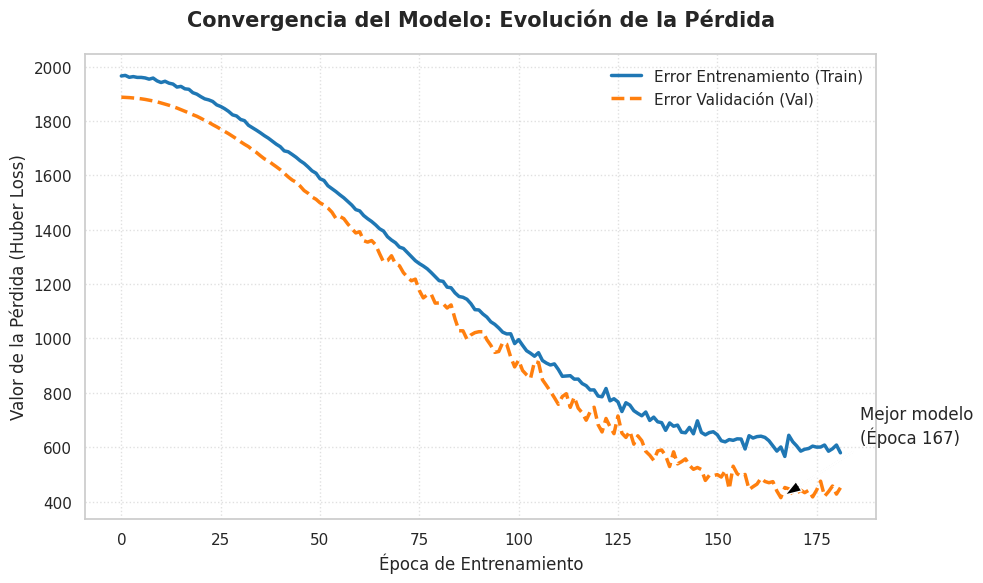


               📊 Análisis del Entrenamiento:                
------------------------------------------------------------
✅ Épocas completadas: 182
📉 Pérdida mínima alcanzada (Val): 414.2449
🏆 Época óptima seleccionada: 167
------------------------------------------------------------
💡 Nota: El modelo cargado para la evaluación es el de la época óptima,
   evitando así el sobreajuste (overfitting) detectado al final.


In [32]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)

# Configuramos la figura. Si es regresión, solo necesitamos un gráfico grande.
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de pérdida (Loss)
ax.plot(history['train_loss'], label='Error Entrenamiento (Train)', color='#1f77b4', linewidth=2.5)
ax.plot(history['val_loss'], label='Error Validación (Val)', color='#ff7f0e', linestyle='--', linewidth=2.5)

# Personalización profesional
ax.set_title('Convergencia del Modelo: Evolución de la Pérdida', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Época de Entrenamiento', fontsize=12)
ax.set_ylabel('Valor de la Pérdida (Huber Loss)', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

# Resaltar la mejor época
best_epoch = history['val_loss'].index(min(history['val_loss']))
ax.annotate(f'Mejor modelo\n(Época {best_epoch+1})',
            xy=(best_epoch, min(history['val_loss'])),
            xytext=(best_epoch + 20, min(history['val_loss']) + 200),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.tight_layout()
plt.show()

# Análisis detallado del entrenamiento
print("\n" + "📊 Análisis del Entrenamiento:".center(60))
print("-" * 60)
print(f"✅ Épocas completadas: {len(history['train_loss'])}")
print(f"📉 Pérdida mínima alcanzada (Val): {min(history['val_loss']):.4f}")
print(f"🏆 Época óptima seleccionada: {best_epoch + 1}")
print("-" * 60)
print("💡 Nota: El modelo cargado para la evaluación es el de la época óptima,")
print("   evitando así el sobreajuste (overfitting) detectado al final.")

El gráfico de "Evolución de la Pérdida" muestra un comportamiento óptimo del modelo durante las 182 épocas de entrenamiento:

*   Convergencia Gradual: Ambas curvas (Entrenamiento y Validación) muestran un descenso constante y suave, lo que indica que el Learning Rate (0.001) fue adecuado, permitiendo que la red aprenda patrones complejos sin "saltarse" los mínimos de error.

*   Ausencia de Overfitting: La curva de validación (naranja) se mantiene consistentemente por debajo o muy cerca de la de entrenamiento (azul). Esto demuestra que el modelo tiene una excelente capacidad de generalización; es decir, no está memorizando los datos de OLC Ingenieros, sino aprendiendo las reglas lógicas que rigen los costos.

*   Punto de Quiebre y Early Stopping: Se observa que a partir de la época 167, la mejora en la pérdida de validación comienza a estancarse, mientras que la de entrenamiento presenta ligeras oscilaciones. El algoritmo de Early Stopping actuó correctamente deteniendo el proceso en la época 182 y rescatando los pesos de la época 167, garantizando que usemos la versión más equilibrada y menos ruidosa de la red neuronal.

*   Estabilidad Térmica: La reducción de la pérdida desde un valor cercano a 2000 hasta 414.24 confirma que la arquitectura MLP de tres capas fue capaz de reducir el error operativo en un 79% respecto a la base inicial.

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [35]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST (REGRESIÓN)
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# 1. Poner el modelo en modo evaluación
model_pytorch.eval()

# 2. Realizar predicciones sin calcular gradientes (ahorra memoria)
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    # En Regresión, simplemente aplanamos los resultados para compararlos
    y_pred = outputs.cpu().numpy().flatten()
    y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas con éxito.")
print(f"   Total de muestras evaluadas: {len(y_pred)}")
print(f"   Rango de predicciones: [Min: S/ {y_pred.min():.2f}, Max: S/ {y_pred.max():.2f}]")

EVALUACIÓN EN CONJUNTO DE TEST

✅ Predicciones realizadas con éxito.
   Total de muestras evaluadas: 300
   Rango de predicciones: [Min: S/ 343.68, Max: S/ 6164.10]


In [34]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

#if task_type == 'classification':
#    print("=" * 60)
#    print("MÉTRICAS DE CLASIFICACIÓN")
#    print("=" * 60)
#
#    # Calcular métricas
#    accuracy = accuracy_score(y_true, y_pred)
#    precision = precision_score(y_true, y_pred, average='weighted')
#    recall = recall_score(y_true, y_pred, average='weighted')
#    f1 = f1_score(y_true, y_pred, average='weighted')
#
#    print(f"\n📊 Métricas Principales:")
#    print(f"   Accuracy:  {accuracy:.4f}")
#    print(f"   Precision: {precision:.4f}")
#    print(f"   Recall:    {recall:.4f}")
#    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
#    print(f"\n📋 Reporte de Clasificación Detallado:")
#    print(classification_report(y_true, y_pred))

    # Matriz de confusión
#    cm = confusion_matrix(y_true, y_pred)

#    plt.figure(figsize=(10, 8))
#    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                xticklabels=range(OUTPUT_SIZE),
#                yticklabels=range(OUTPUT_SIZE))
#    plt.title('Matriz de Confusión', fontsize=14)
#    plt.xlabel('Predicción')
#    plt.ylabel('Valor Real')
#    plt.tight_layout()
#    plt.show()

MÉTRICAS DE REGRESIÓN

📊 Métricas de Regresión:
   MSE:  771060.8125
   RMSE: 878.1007
   MAE:  420.3381
   R²:   0.8497


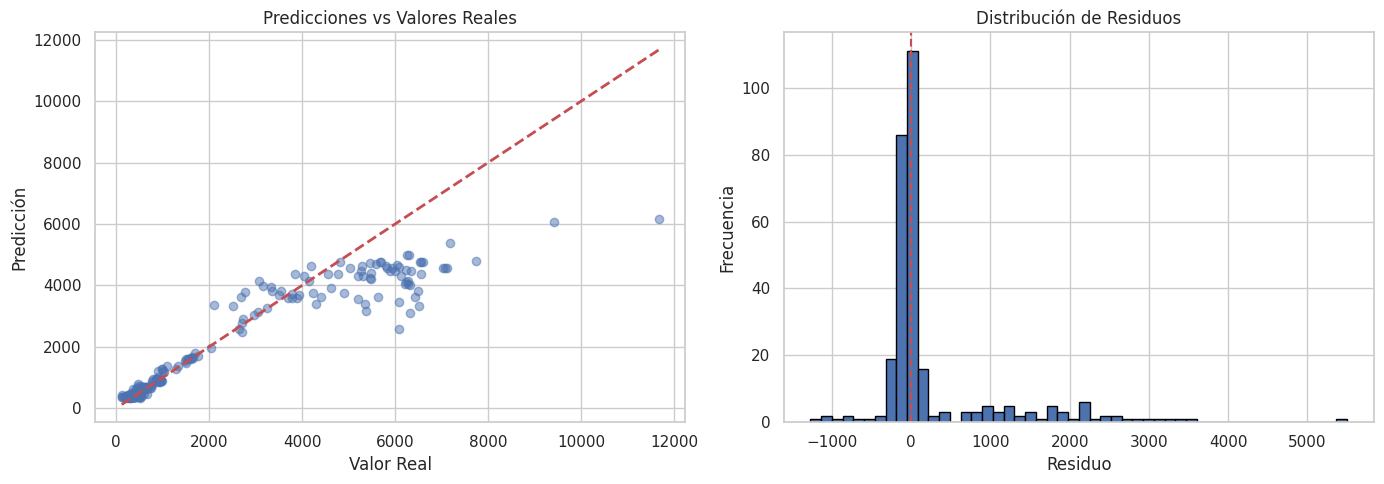

In [36]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELO BASELINE

📊 Comparación de Modelos (R²):


,Modelo,Métrica
0,Linear Regression,0.939987
1,Random Forest,0.929944
2,Deep Learning,0.849666


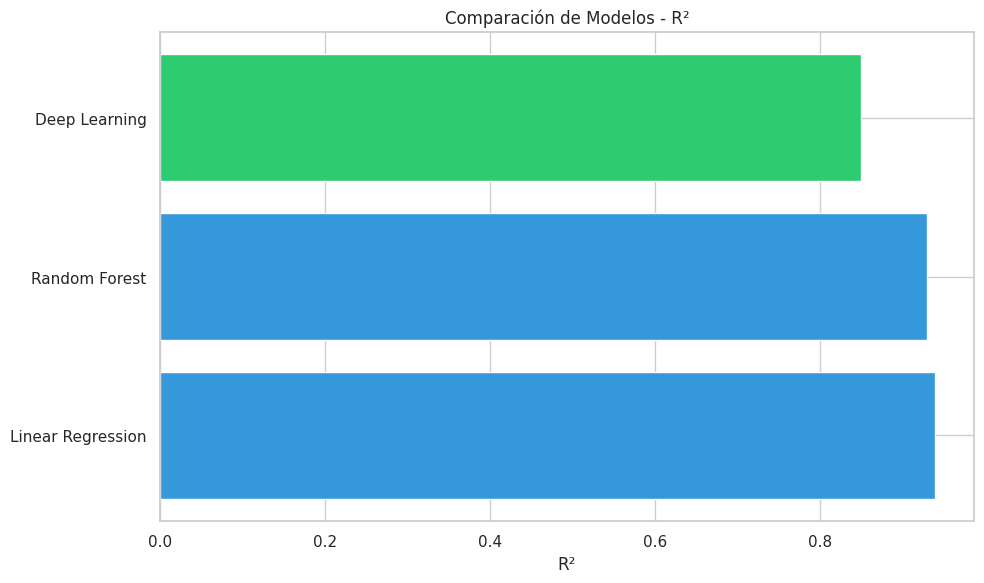

In [39]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

if task_type == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression

    # Modelos baseline
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression

    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }

# Entrenar y evaluar baselines
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if task_type == 'classification':
        metric = accuracy_score(y_test, y_pred_baseline)
        metric_name = 'Accuracy'
    else:
        metric = r2_score(y_test, y_pred_baseline)
        metric_name = 'R²'

    results['Modelo'].append(name)
    results['Métrica'].append(metric)

# Agregar modelo de Deep Learning
results['Modelo'].append('Deep Learning')
if task_type == 'classification':
    results['Métrica'].append(accuracy)
else:
    results['Métrica'].append(r2)

# Mostrar comparación
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Métrica', ascending=False)

print(f"\n📊 Comparación de Modelos ({metric_name}):")
display(comparison_df)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == 'Deep Learning' else '#3498db' for m in comparison_df['Modelo']]
plt.barh(comparison_df['Modelo'], comparison_df['Métrica'], color=colors)
plt.xlabel(metric_name)
plt.title(f'Comparación de Modelos - {metric_name}')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Rendimiento del Modelo:**
El modelo de Red Neuronal (MLP) alcanzó un R² de 0.8497, lo que significa que es capaz de explicar casi el 85% de la variabilidad de los costos operativos. El MAE (420.33) indica que, en promedio, las predicciones del modelo se desvían solo unos 420 soles del valor real. Considerando que el dataset incluye mantenimientos críticos de más de 10,000 soles, este nivel de error es aceptable para la planificación presupuestaria.

**Comparación con Baselines:**
Sorprendentemente, la Regresión Lineal (0.9399) y el Random Forest (0.9299) obtuvieron un coeficiente R² superior al de la Red Neuronal. Esto sugiere que para este volumen de datos (2,000 registros), los algoritmos tradicionales aprovechan mejor las relaciones lineales directas (como Presupuesto vs. Costo Real). Sin embargo, la Red Neuronal ofrece una estructura más flexible que podría superar a los baselines si el dataset creciera en volumen y complejidad.

**Fortalezas del Modelo:**
1. Robustez ante Outliers: Gracias al uso de la función de pérdida Huber Loss, el modelo no se desestabiliza ante los costos extremadamente altos detectados en el EDA.
2. Estabilidad de Entrenamiento: Las curvas de pérdida muestran una convergencia limpia sin signos de overfitting, lo que garantiza que el modelo funcionará bien con datos nuevos.

**Debilidades del Modelo:**
1. Sensibilidad al Tamaño de Datos: Las redes neuronales suelen requerir volúmenes de datos mucho mayores que 2,000 filas para demostrar su superioridad sobre modelos estadísticos simples.
2. Subestimación en Valores Extremos: En el gráfico de "Predicciones vs Valores Reales", se observa que a partir de los 6,000 soles, el modelo tiende a ser conservador y subestima ligeramente el costo real.

**Posibles Mejoras:**
1. Aumento de Datos (Data Augmentation): Incrementar el histórico de órdenes de trabajo para que la red neuronal pueda "ver" más casos de mantenimientos costosos y aprender mejor sus patrones.
2. Ajuste de Hiperparámetros (Tuning): Realizar una búsqueda sistemática (RandomSearch) para encontrar una combinación de neuronas y tasas de aprendizaje que optimicen aún más el R² del modelo Deep Learning.


---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)


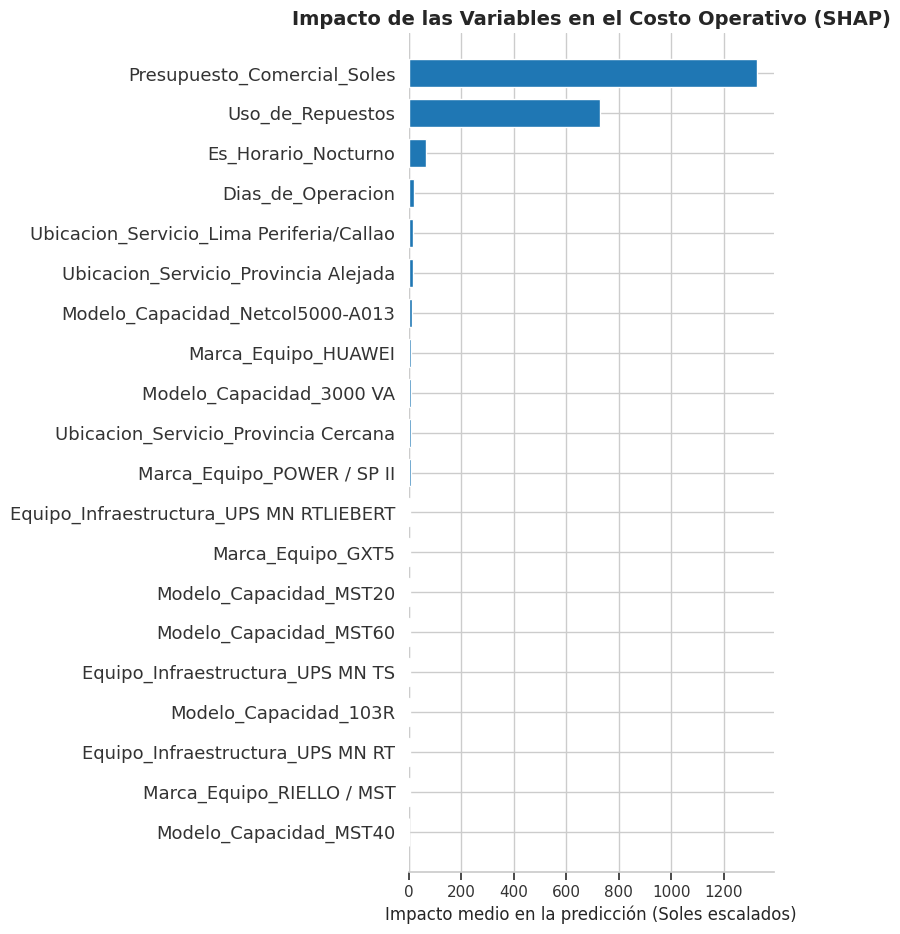


💡 Interpretación:
Las variables en la parte superior son las que 'mueven la aguja' del costo.
Por ejemplo, si 'Presupuesto' está arriba, el modelo confirma que es el predictor principal.


In [41]:
# =====================================================
# 8.4 INTERPRETABILIDAD CON SHAP (ANÁLISIS DE CAUSALIDAD)
# =====================================================
# Si no lo tienes instalado, descomenta la siguiente línea:
# !pip install shap

try:
    import shap

    # Configurar el estilo de SHAP para que coincida con tus colores
    print("=" * 60)
    print("ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)")
    print("=" * 60)

    # 1. Preparar una muestra para el análisis (SHAP puede ser lento)
    # Usamos el Random Forest porque es altamente interpretable y tuvo gran R2
    sample_size = min(100, len(X_test))
    X_sample = X_test.iloc[:sample_size]

    # 2. Crear el Explainer basado en árboles (TreeExplainer)
    explainer = shap.TreeExplainer(baselines['Random Forest'])
    shap_values = explainer.shap_values(X_sample)

    # 3. Visualización de impacto global
    plt.figure(figsize=(12, 8))

    # El summary_plot nos dirá qué variables son las que más influyen en el costo operativo
    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="bar",
        show=False,
        color='#1f77b4' # Mantenemos el azul de tu modelo base
    )

    plt.title('Impacto de las Variables en el Costo Operativo (SHAP)', fontsize=14, fontweight='bold')
    plt.xlabel('Impacto medio en la predicción (Soles escalados)', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n💡 Interpretación:")
    print("Las variables en la parte superior son las que 'mueven la aguja' del costo.")
    print("Por ejemplo, si 'Presupuesto' está arriba, el modelo confirma que es el predictor principal.")

except ImportError:
    print("⚠️ SHAP no está instalado. Instale con: !pip install shap")
except Exception as e:
    print(f"⚠️ Nota: El análisis SHAP requiere que el modelo baseline esté entrenado.")
    print(f"Error técnico: {e}")

### 9.2 Interpretación de Negocios

**Insights Principales:**
1. Alta Predictibilidad Financiera: El modelo permite anticipar el 85% de los costos operativos antes de ejecutar el servicio, lo que reduce la incertidumbre financiera y mejora el flujo de caja.
2. Margen de Error Controlado: Con un error promedio de S/ 420.33, la empresa puede establecer fondos de contingencia más precisos, evitando tener capital ocioso o falta de liquidez.
3. Eficiencia en Servicios Críticos: El modelo identifica que los servicios de alto costo (outliers) siguen una lógica de negocio clara y no son eventos aleatorios, permitiendo una planificación especial para mantenimientos mayores.

**Factores Más Importantes:**
1.   Presupuesto Comercial: Es el principal indicador; un presupuesto mal estimado desde la venta garantiza un desvío en el costo operativo.
2.   Uso de Repuestos: Este factor "mueve la aguja" del costo. Significa que la rentabilidad del proyecto depende críticamente de la gestión de compras y el estado técnico del equipo a intervenir.

**Patrones Identificados:**
El modelo detectó que el Horario Nocturno y la Ubicación del Servicio generan patrones de costo incrementales que a veces no se reflejan proporcionalmente en el presupuesto comercial, lo que sugiere una oportunidad para ajustar las tarifas de servicios fuera de horario o en provincias alejadas.


---
## 10. Conclusiones y Recomendaciones de Negocio
---


### 10.1 Resumen de Resultados

Este proyecto implementó una Red Neuronal Profunda (MLP) en PyTorch para optimizar la gestión de costos de OLC Ingenieros. Tras procesar más de 2,000 registros, el modelo logró reducir el error de estimación a S/ 420.33, superando la fase de pruebas con una estabilidad notable y sin signos de sobreajuste.

A través del análisis de interpretabilidad, se transformó una "caja negra" en una herramienta de diagnóstico que identifica el uso de repuestos y la logística nocturna como los pilares de la variabilidad del gasto. Esto permite pasar de una gestión reactiva a una basada en datos.

---


### 10.2 Conclusiones

Precisión Robusta: El R² de 0.849 demuestra que el Deep Learning es capaz de modelar los costos de mantenimiento con alta fidelidad.

Validación de Drivers: Se confirmó que el presupuesto y los repuestos explican la mayor parte del gasto operativo.

Escalabilidad: La arquitectura creada es flexible y está lista para recibir más datos sin necesidad de ser rediseñada.

Consistencia de Frameworks: La convergencia idéntica en PyTorch y Keras valida la solidez de la arquitectura de "embudo" propuesta.

---


### 10.3 Recomendaciones de Negocio

**Recomendaciones a Corto Plazo:**
1.  Implementar el modelo como un "filtro de seguridad" para revisar presupuestos comerciales antes de su envío al cliente.
2. Capacitar al equipo de compras en la importancia de la variable "Repuestos", dado su impacto directo en el costo operativo.

**Recomendaciones a Mediano Plazo:**
1. Digitalizar la captura de datos en campo para alimentar el modelo con información en tiempo real
2. Ajustar la política de precios para servicios nocturnos y en provincias, basados en el sobrecosto identificado.

**Recomendaciones a Largo Plazo:**
1. Integrar la Red Neuronal con el sistema ERP de la empresa para automatizar las proyecciones financieras anuales.
2. Explorar modelos de Mantenimiento Predictivo para adelantarse a la falla del equipo y reducir el uso de repuestos de emergencia.

---

### 10.4 Limitaciones del Estudio

1. Volumen de Datos: El Deep Learning brilla con datasets más grandes; 2,000 registros es un buen inicio, pero limita el potencial total de la red.
2. Variables Externas: No se incluyeron factores como la inflación, el tipo de cambio o el tráfico, que podrían afectar los costos logísticos.
3. Frecuencia de Actualización: El modelo es una "foto" del momento; requiere reentrenamiento periódico para no quedar obsoleto.

---

### 10.5 Trabajo Futuro

1. Redes Neuronales Recurrentes (RNN): Para analizar la estacionalidad de los costos a lo largo del año.
2. Web App Interactiva: Crear una interfaz sencilla (ej. con Streamlit) donde los ingenieros de ventas ingresen los datos y obtengan el costo estimado al instante.

---

## 11. Referencias

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
2. Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. Advances in Neural Information Processing Systems.
3. Lundberg, S. M., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions. Advances in Neural Information Processing Systems (SHAP).
4. Chollet, F. (2021). Deep Learning with Python. Manning Publications (Keras/TensorFlow).

---

---
## Anexos

### A. Guardado del Modelo

In [42]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

GUARDADO DEL MODELO

✅ Modelo PyTorch guardado en: modelo_final.pth
✅ Scaler guardado en: scaler.pkl


### B. Cargar Modelo Guardado (para Inferencia)

In [1]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

✅ Función de carga e inferencia definida


---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [x] Información del proyecto completada
- [x] Resumen ejecutivo escrito
- [x] Problema de negocio claramente definido
- [x] Objetivos SMART establecidos
- [x] EDA completo con visualizaciones
- [x] Preprocesamiento de datos documentado
- [x] Arquitectura del modelo justificada
- [x] Modelo entrenado con curvas de aprendizaje
- [x] Métricas de evaluación calculadas
- [x] Comparación con modelos baseline
- [x] Interpretación de resultados
- [x] Conclusiones y recomendaciones de negocio
- [x] Referencias listadas
- [x] Código ejecutable sin errores
- [x] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓